In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import os
from typing import Dict
import pickle
from scipy.stats import linregress


def set_default_plot_style():
    plt.style.use("default")  # start clean

    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.2
    plt.rcParams["grid.linestyle"] = "-"
    plt.rcParams["grid.color"] = "gray"

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    plt.rcParams["axes.linewidth"] = 1.2

    plt.rcParams["legend.frameon"] = False

    plt.rcParams["font.size"] = 23
    plt.rcParams["axes.labelsize"] = 30
    plt.rcParams["legend.fontsize"] = 18

    # plt.rcParams["font.size"] = 18
    # plt.rcParams["axes.labelsize"] = 24
    # plt.rcParams["legend.fontsize"] = 12

    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Computer Modern Roman']

# Call once at the top of your script
set_default_plot_style()


In [2]:
# Helpful funcs
def log_b(x, b):
    return np.log(x) / np.log(b)


In [3]:
L_vals = [1000, 2000, 4000, 8000, 16000]

epdilon_vals = [0.2537, 0.253725]
a_val = 1/2
a_val_name = f"{a_val}".replace(".", "p")

time_prefact = 5000

num_initial_conds = 5792
initial_state_prob = 0.5

time_step = 150000

cmap = plt.colormaps.get_cmap("Blues").resampled(len(epdilon_vals) + 10)
cmap2 = plt.colormaps.get_cmap("Oranges").resampled(len(L_vals) + 5)


read_external_drive = True
write_external_drive = read_external_drive and True
local_data_parent_folder = "data"
if read_external_drive:
    data_parent_folder = "/Volumes/ExternalData/stavskya_mc/data"
else:
    data_parent_folder = local_data_parent_folder


In [24]:
# If first time

collected_rhos = {}
collected_rho_stds = {}

counts = []
for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = round(L_val*time_prefact)
    collected_rhos[L_val] = {}
    collected_rho_stds[L_val] = {}

    for epdilon in epdilon_vals:
        print(f"L_val: {L_val} | epsilon: {epdilon}")
        epsilon_val_name = f"{epdilon}".replace(".", "p")

        current_rhos = [[0.0 for _ in range(round(L_val * time_prefact / time_step))] for _ in range(num_initial_conds)]
        count = 0
        for init_cond in range(1, num_initial_conds+1):
            sample_filepath_name = os.path.join(data_parent_folder, f"time_rand_n/rho_per_time/IC1/L{L_val}/a{a_val_name}/epsilon{epsilon_val_name}/IC1_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}_sample{init_cond}.csv")
            try:
                df = pd.read_csv(sample_filepath_name)

                current_rhos[count] = df.rho
                count += 1
            except Exception as e:
                print(e)
                print(sample_filepath_name)

        counts.append(count)
        current_rhos = current_rhos[0:count]

        current_rhos = np.array(current_rhos)
        collected_rhos[L_val][epdilon] = np.mean(current_rhos.T, axis=1)
        collected_rho_stds[L_val][epdilon] = np.std(current_rhos.T, axis=1)

        pickle_path = os.path.join(data_parent_folder, f"time_rand_n/rho_per_time/IC1/L{L_val}/a{a_val_name}/epsilon{epsilon_val_name}/IC1_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")
        second_pickle_path = os.path.join(local_data_parent_folder, f"time_rand_n/rho_per_time/IC1/L{L_val}/a{a_val_name}/epsilon{epsilon_val_name}/IC1_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")
        
        dir_path = os.path.dirname(pickle_path)
        os.makedirs(dir_path, exist_ok=True)
        
        with open(pickle_path + "mean.pickle", "wb") as f:
            pickle.dump(collected_rhos[L_val][epdilon], f)
        with open(pickle_path + "stds.pickle", "wb") as f:
            pickle.dump(collected_rho_stds[L_val][epdilon], f)
        
        try:
            dir_path2 = os.path.dirname(second_pickle_path)
            os.makedirs(dir_path2, exist_ok=True)
            
            with open(second_pickle_path + "mean.pickle", "wb") as f:
                pickle.dump(collected_rhos[L_val][epdilon], f)
            with open(second_pickle_path + "stds.pickle", "wb") as f:
                pickle.dump(collected_rho_stds[L_val][epdilon], f)
        except Exception as e:
            print(e)

print(min(counts))

L_val: 1000
L_val: 1000 | epsilon: 0.2537
L_val: 1000 | epsilon: 0.253725
L_val: 2000
L_val: 2000 | epsilon: 0.2537
L_val: 2000 | epsilon: 0.253725
L_val: 4000
L_val: 4000 | epsilon: 0.2537
L_val: 4000 | epsilon: 0.253725
L_val: 8000
L_val: 8000 | epsilon: 0.2537
L_val: 8000 | epsilon: 0.253725
L_val: 16000
L_val: 16000 | epsilon: 0.2537
L_val: 16000 | epsilon: 0.253725
5792


In [12]:
print(counts)

[2158, 3929, 3929, 3929, 3929, 3929, 2158, 3929, 2158, 1727]


In [4]:

collected_rhos = {}
collected_rho_stds = {}

for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_rhos[L_val] = {}
    collected_rho_stds[L_val] = {}

    collected_rhos[L_val] = {}
    collected_rho_stds[L_val] = {}
    for epdilon in epdilon_vals:
        epsilon_val_name = f"{epdilon}".replace(".", "p")
        pickle_path = os.path.join(data_parent_folder, f"time_rand_n/rho_per_time/IC1/L{L_val}/a{a_val_name}/epsilon{epsilon_val_name}/IC1_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")
        
        try:
            with open(pickle_path + "mean.pickle", "rb") as f:
                collected_rhos[L_val][epdilon] = pickle.load(f)
            with open(pickle_path + "stds.pickle", "rb") as f:
                collected_rho_stds[L_val][epdilon] = pickle.load(f)
        except Exception as e:
            print(e)
            pickle_path = os.path.join(local_data_parent_folder, f"time_rand_n/rho_per_time/IC1/L{L_val}/a{a_val_name}/epsilon{epsilon_val_name}/IC1_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")
            with open(pickle_path + "mean.pickle", "rb") as f:
                collected_rhos[L_val][epdilon] = pickle.load(f)
            with open(pickle_path + "stds.pickle", "rb") as f:
                collected_rho_stds[L_val][epdilon] = pickle.load(f)
            print("\t Loaded from local")


L_val: 1000
[Errno 2] No such file or directory: '/Volumes/ExternalData/stavskya_mc/data/time_rand_n/rho_per_time/IC1/L1000/a0p5/epsilon0p2537/IC1_L1000_epsilon0p2537_timepref5000_timestep150000mean.pickle'
	 Loaded from local
[Errno 2] No such file or directory: '/Volumes/ExternalData/stavskya_mc/data/time_rand_n/rho_per_time/IC1/L1000/a0p5/epsilon0p253725/IC1_L1000_epsilon0p253725_timepref5000_timestep150000mean.pickle'
	 Loaded from local
L_val: 2000
[Errno 2] No such file or directory: '/Volumes/ExternalData/stavskya_mc/data/time_rand_n/rho_per_time/IC1/L2000/a0p5/epsilon0p2537/IC1_L2000_epsilon0p2537_timepref5000_timestep150000mean.pickle'
	 Loaded from local
[Errno 2] No such file or directory: '/Volumes/ExternalData/stavskya_mc/data/time_rand_n/rho_per_time/IC1/L2000/a0p5/epsilon0p253725/IC1_L2000_epsilon0p253725_timepref5000_timestep150000mean.pickle'
	 Loaded from local
L_val: 4000
[Errno 2] No such file or directory: '/Volumes/ExternalData/stavskya_mc/data/time_rand_n/rho_per

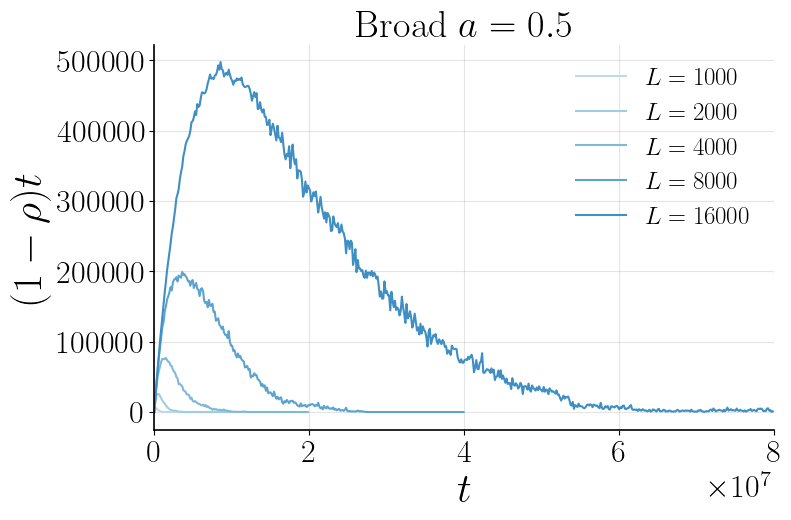

In [5]:
epsilon_c = 0.253725

C = 12
tf = 0.15 * 10**8
plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    c = cmap(j+3)
    time_vals = np.array([i * time_step for i in range(0, round(L*time_prefact / time_step))])
    orig_data = 1-collected_rhos[L][epsilon_c]
    plt.plot(
        (time_vals)[0::], 
        (orig_data * time_vals)[0::], 
        label = fr"$L = {L}$",
        # fmt='--',  
        # markersize=3,
        # marker = "o",
        # capsize=3,
        c=c
        )
    # plt.axvline(C * L ** 1.4, c=c)


plt.xlabel(r"$t$")
plt.ylabel(r"$(1 - \rho)t$")
plt.legend()
plt.title(fr"Broad $a = {a_val}$")
# plt.xlim(np.log10(0.001), np.log10(1))
# plt.ylim(0.7, 0.77)
plt.xlim(0, 0.8 * 10**8)

plt.show()

/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_36854/3993514281.py:8: RuntimeWarning: divide by zero encountered in log10
  np.log10(time_vals)[1::],


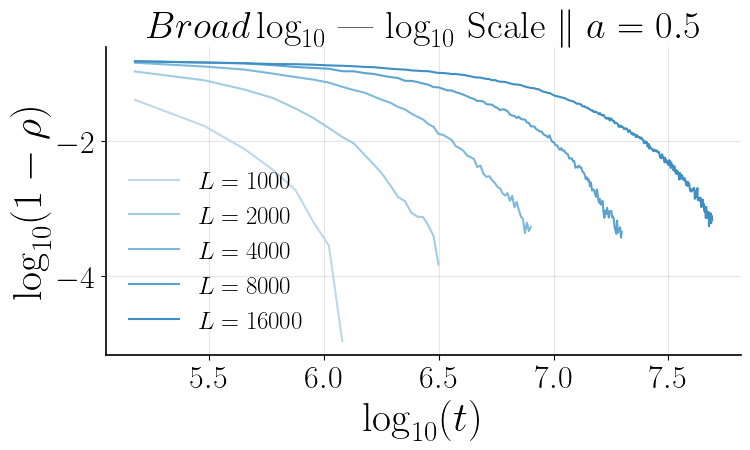

In [6]:

plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    c = cmap(j+3)
    time_vals = np.array([i * time_step for i in range(0, round(L*time_prefact / time_step))])
    time_vals = [t for t in time_vals if t <= 14.0* C * L ** 1.3]
    orig_data = (1-collected_rhos[L][epsilon_c])[0:len(time_vals)]
    plt.plot(
        np.log10(time_vals)[1::], 
        np.log10((orig_data))[1::], 
        label = fr"$L = {L}$",
        # fmt='--',  
        # markersize=3,
        # marker = "o",
        # capsize=3,
        c=c
        )

# plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
plt.title(fr"$Broad \log_{{10}}$ | $\log_{{10}}$ Scale $\|$ $a = {a_val}$")
plt.xlabel(r"$\log_{10}(t)$")
plt.ylabel(r"$\log_{10}(1 - \rho)$")
plt.legend()
# plt.xlim(np.log10(0.001), np.log10(1))
# plt.ylim(0.7, 0.77)
plt.tight_layout()
# plt.savefig(f"figs/time_random/n_a{a_val_name}/z_estimate.png")

plt.show()

/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_36854/1329433789.py:12: RuntimeWarning: divide by zero encountered in log10
  np.log10((time_vals/(L ** z_guess)))[0::],
/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_36854/1329433789.py:13: RuntimeWarning: divide by zero encountered in log10
  np.log10((orig_data * time_vals ** found_delta))[0::],


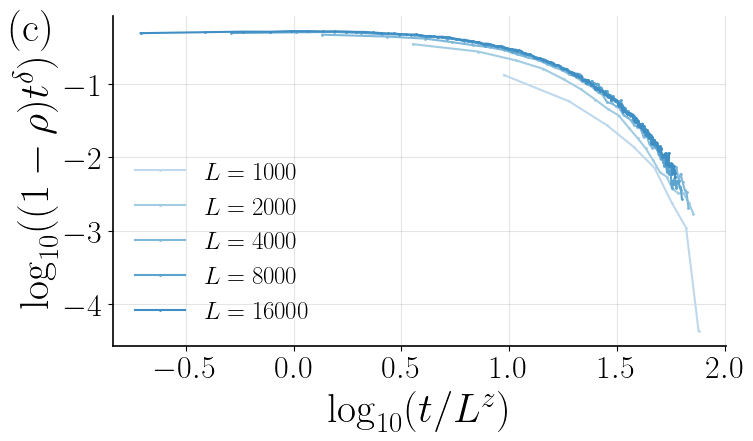

In [73]:
epsilon_c = 0.253725
z_guess = 1.4
found_delta = 0.1

fig = plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    c = cmap(j+3)
    time_vals = [i * time_step for i in range(0, round(L*time_prefact / time_step))]
    time_vals = np.array([t for t in time_vals if t <= 13.0* C * L ** 1.3])
    orig_data = np.array((1-collected_rhos[L][epsilon_c])[0:len(time_vals)])
    plt.plot(
        np.log10((time_vals/(L ** z_guess)))[0::], 
        np.log10((orig_data * time_vals ** found_delta))[0::], 
        label = fr"$L = {L}$",
        # fmt='--',  
        markersize=1,
        marker = "o",
        # capsize=3,
        c=c
        )

# plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
# plt.title(fr"Broad: $a = {a_val}$ Collapse $\|$ $\epsilon = {epsilon_c}$ $\|$ $\delta = {found_delta}$ $\|$ $z = {z_guess}$")
plt.text(0.04, 0.85, "(c)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)

plt.xlabel(r"$\log_{10}(t/L^z)$")
plt.ylabel(r"$\log_{10}((1 - \rho)t^\delta)$")
plt.legend()
# plt.xlim(np.log10(0.001), np.log10(1))
# plt.ylim(0.7, 0.77)
plt.tight_layout()
plt.savefig(f"figs/time_random/broad/broadstav_determining_z.png")
plt.show()

In [5]:
epsilon_c = 0.253725
z_guess = 1.4
found_delta = 0.1
plt.rcParams["axes.linewidth"] = 3.5

fig = plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    if L <= 2000:
        continue
    c = cmap(j+3)
    time_vals = [i * time_step for i in range(0, round(L*time_prefact / time_step))]
    time_vals = np.array([t for t in time_vals if t <= 13.0* C * L ** 1.3])
    orig_data = np.array((1-collected_rhos[L][epsilon_c])[0:len(time_vals)])
    plt.plot(
        np.log10((time_vals/(L ** z_guess)))[0::], 
        np.log10((orig_data * time_vals ** found_delta))[0::], 
        label = fr"$L = {L}$",
        # fmt='--',  
        markersize=1,
        marker = "o",
        # capsize=3,
        c=c, linewidth=2
        )

# plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
# plt.title(fr"Broad: $a = {a_val}$ Collapse $\|$ $\epsilon = {epsilon_c}$ $\|$ $\delta = {found_delta}$ $\|$ $z = {z_guess}$")
# plt.text(0.04, 0.85, "(c)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)

plt.xlabel(r"$\log_{10}(t/L^z)$", fontsize=45)
plt.ylabel(r"$\log_{10}((1 - \rho)t^\delta)$",fontsize=45)
plt.tick_params(labelbottom=True, labelleft=True, length=3, labelsize=45)
plt.grid(False)


# plt.legend()
# plt.xlim(np.log10(0.001), np.log10(1))
# plt.ylim(0.7, 0.77)
plt.tight_layout()
plt.savefig(f"figs/time_random/broad/broadstav_determining_z_for_inset.png")
plt.show()

plt.rcParams["axes.linewidth"] = 1.2

NameError: name 'C' is not defined

<Figure size 800x500 with 0 Axes>

/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_36854/1744500146.py:20: RuntimeWarning: divide by zero encountered in log10
  np.log10(time_vals)[1:],
/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_36854/1744500146.py:28: RuntimeWarning: divide by zero encountered in log10
  np.log10(time_vals / (L ** z_guess))[1:],
/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_36854/1744500146.py:29: RuntimeWarning: divide by zero encountered in log10
  np.log10(orig_data * time_vals ** found_delta)[1:],


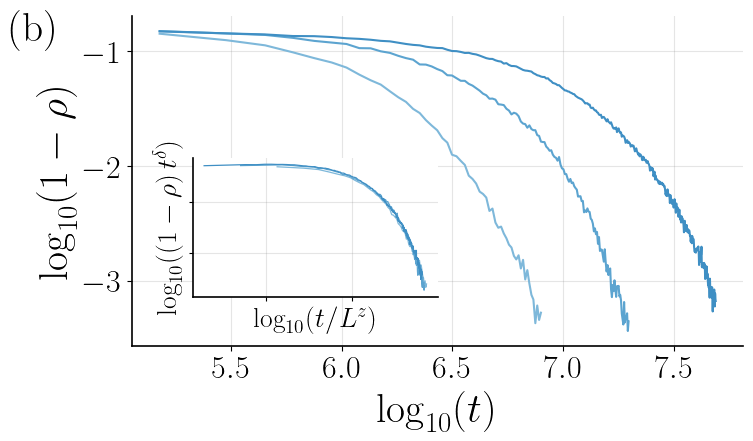

In [23]:
epsilon_c = 0.253725
z_guess = 1.4
found_delta = 0.1

fig, ax = plt.subplots(figsize=(8, 5))

# --- Inset axes (collapsed data) ---
ax_inset = ax.inset_axes([0.1, 0.15, 0.4, 0.42])

for j, L in enumerate(L_vals):
    if L <= 2000:
        continue
    c = cmap(j + 3)
    time_vals = np.array([i * time_step for i in range(0, round(L * time_prefact / time_step))])
    time_vals = np.array([t for t in time_vals if t <= 14.0 * C * L ** 1.3])
    orig_data = np.array((1 - collected_rhos[L][epsilon_c])[0:len(time_vals)])

    # Main raw data plot
    ax.plot(
        np.log10(time_vals)[1:],
        np.log10(orig_data)[1:],
        label=fr"$L = {L}$",
        c=c
    )

    # Inset collapse plot
    ax_inset.plot(
        np.log10(time_vals / (L ** z_guess))[1:],
        np.log10(orig_data * time_vals ** found_delta)[1:],
        c=c,
        lw=0.9,
        markersize=1,
        # marker="o",
    )

# --- Inset formatting ---
ax_inset.set_xlabel(r"$\log_{10}(t/L^z)$", fontsize=20)
ax_inset.set_ylabel(r"$\log_{10}((1-\rho)\,t^\delta)$", fontsize=20)
ax_inset.tick_params(labelbottom=False, labelleft=False, length=3)
ax_inset.set_facecolor(fig.get_facecolor())

# --- Main axes formatting ---
ax.text(0.04, 0.85, "(b)", fontsize=plt.rcParams["axes.labelsize"], transform=fig.transFigure)
ax.set_xlabel(r"$\log_{10}(t)$")
ax.set_ylabel(r"$\log_{10}(1 - \rho)$")
# ax.legend(loc="upper left")
fig.tight_layout()

plt.savefig(f"figs/time_random/broad/broadstav_determining_z.png")
plt.show()

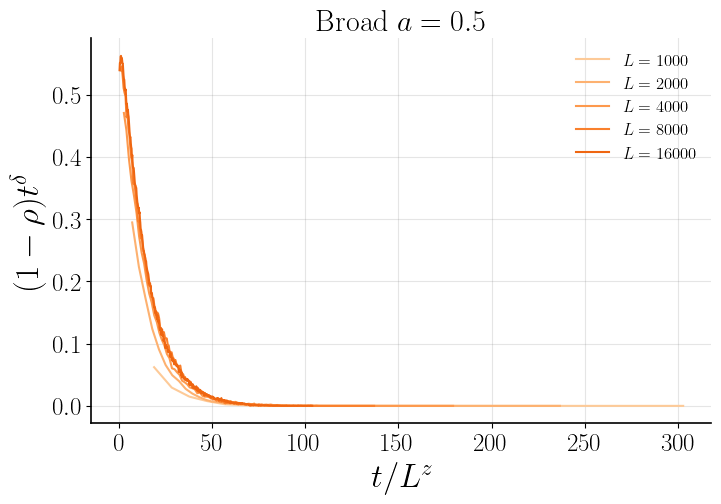

In [93]:
epsilon_c = 0.253725
z_guess = 1.4
found_delta = 0.105

tf = 0.15 * 10**8
plt.figure(figsize=(8,5))
for j, L in enumerate(L_vals):
    c = cmap(j+3)
    time_vals = np.array([i * time_step for i in range(0, round(L*time_prefact / time_step))])
    orig_data = 1-collected_rhos[L][epsilon_c]
    plt.plot(
        (time_vals/(L**z_guess))[2::], 
        (orig_data * (time_vals**found_delta))[2::], 
        label = fr"$L = {L}$",
        # fmt='--',  
        # markersize=3,
        # marker = "o",
        # capsize=3,
        c=c
        )


plt.xlabel(r"$t/L^z$")
plt.ylabel(r"$(1 - \rho)t^\delta$")
plt.legend()
plt.title(fr"Broad $a = {a_val}$")
# plt.xlim(np.log10(0.001), np.log10(1))
# plt.ylim(0.7, 0.77)
# plt.xlim(0, 0.8 * 10**8)

plt.show()